In [1]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,START,END
from langchain_core.documents import Document
from pydantic import BaseModel,Field
from typing import List,TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os
import re
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
import warnings 
warnings.filterwarnings('ignore')
load_dotenv()

c:\Users\DHRUV AGARWAL\Desktop\RAG-Retrieval-Augmented-Generation-\RAG1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
docs=(
    PyPDFLoader(r"./documents/book1 (1).pdf").load() +
    PyPDFLoader(r"./documents/book2 (1).pdf").load() + 
    PyPDFLoader(r"./documents/book3 (1).pdf").load()
)

In [6]:
len(docs)

2123

In [7]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content=d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [8]:
len(chunks)

6685

In [9]:
import warnings
warnings.filterwarnings("ignore")

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

In [10]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [11]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={'k':4})

In [12]:
llm=ChatGroq(model="llama-3.3-70b-versatile",api_key=os.getenv("GROQ_API_KEY"))

In [13]:
UPPER_TH=0.7
LOWER_TH=0.3

In [14]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    
    answer: str


In [15]:
def retriever_node(state:State)-> State:
    q=state["question"]
    return {"docs":retriever.invoke(q)}

In [16]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:

    q = state["question"]
    
    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [17]:
#--------------------------
# SENTENCE-LEVEL DECOMPOSER
#--------------------------
def decompose_to_sentences(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentences=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentences if len(s.strip())>20]

#-------------------
# FILTER (LLM JUDGE)
#-------------------
class KeepOrDrop(BaseModel):
    keep: bool = Field(description="true if relevant, false if not. Must be a JSON boolean (true/false), not a string.")

filter_prompt=ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentences.Output JSON only."
    ),
    (
        "human",
        "Question: {question}\n\n Sentence: \n {sentence}"
    )
])

filter_chain=filter_prompt | llm.with_structured_output(KeepOrDrop)

#---------------------------------------------
# REFINING (DECOMPOSE -> FILTER -> Recompose)
#---------------------------------------------

def refine_node(state:State)-> State:
    q=state["question"]
    #combined retrieved docs into one context string .Now we can search the context from the good docs as it contains the relevant and most prcious information 
    context="\n\n".join(d.page_content for d in state["good_docs"]).strip()
    #1)DECOMPOSITION: context ->sentence strips
    strips=decompose_to_sentences(context)
    #2)FILTERING: strips -> keep only the relevant strips
    kept: List[str]=[]
    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    # 3) RECOMPOSE: glue kept strips back together(internal knowledge)
    refined_context="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }


In [18]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate_node(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [19]:
def fail_node(state:State)->State:
    return {"answer":f"FAIL:{state['reason']}"}

def ambiguous_node(state:State)->State:
    return {"answer":f"AMBIGUOUS:{state['reason']}"}

def route_after_eval_node(state:State)->State:
    if state['verdict']=="CORRECT":
        return "refine"
    if state['verdict']=="INCORRECT":
        return "web_search"
    else:
        return "ambiguous"


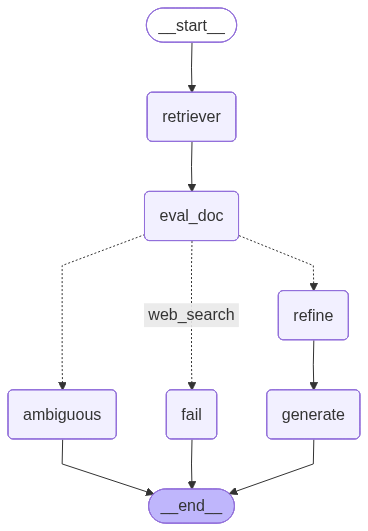

In [20]:
g=StateGraph(State)
g.add_node("retriever",retriever_node)
g.add_node("eval_doc",eval_each_doc_node)
g.add_node("refine",refine_node)
g.add_node("generate",generate_node)
g.add_node("fail",fail_node)
g.add_node("ambiguous",ambiguous_node)
g.add_edge(START,"retriever")
g.add_edge("retriever","eval_doc")
g.add_conditional_edges(
    "eval_doc",
    route_after_eval_node,
    {"refine":"refine","web_search":"fail","ambiguous":"ambiguous"}
)
g.add_edge("refine","generate")
g.add_edge("generate",END)
g.add_edge("fail",END)
app=g.compile()
app

In [21]:
res = app.invoke(
    {
        "question": "What are the differnces between the bias and varience?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

OUTPUT:
 * Bias measures the expected deviation from the true value of the function or parameter.
* Variance provides a measure of the deviation from the expected estimator value that any particular sampling of the data is likely to cause.
* A high-bias model is most likely to underfit the training data.
* A model with high variance is excessively sensitive to small variations in the training data.
